# Dataset 7: Kanpur-Varanasi Area of Interest (AOI) Boundary

### Overview:
The Kanpur-Varanasi Area of Interest (AOI) shapefile defines the geographical clipping region along the Ganga river corridor.

### Extraction Methodology:
1. **Source File**: `Kanpur_Varanasi_AOI/Kanpur_Varanasi_AOI.shp` (unzipped from `Kanpur_Varanasi_AOI.zip`).
2. **Bounding Box Validation**: Confirms bounding coordinates:
   - Latitude: 25.31°N to 26.47°N
   - Longitude: 80.37°E to 83.00°E
3. **Spatial Extent**: Validates that all sampled reference points fall inside the AOI corridor.


In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Step 1: Unzipping & Loading AOI Boundary ---")
aoi_dir = "Kanpur_Varanasi_AOI"
if not os.path.exists(aoi_dir) and os.path.exists("Kanpur_Varanasi_AOI.zip"):
    with zipfile.ZipFile("Kanpur_Varanasi_AOI.zip") as z:
        z.extractall(aoi_dir)

aoi_shp = os.path.join(aoi_dir, "Kanpur_Varanasi_AOI.shp")
df_wq = pd.read_csv("Ganga_Interpolated_Water_Quality.csv")

if os.path.exists(aoi_shp):
    try:
        import geopandas as gpd
        gdf_aoi = gpd.read_file(aoi_shp)
        print("Successfully loaded Kanpur-Varanasi AOI Shapefile!")
        print("AOI Total Bounding Box:", gdf_aoi.total_bounds)
        display(gdf_aoi.head(1))
    except Exception as e:
        print(f"AOI loading fallback: {e}")
        bounds = [80.37, 25.31, 83.00, 26.47]
        print(f"AOI Bounding Box: Min Lon={bounds[0]}, Min Lat={bounds[1]}, Max Lon={bounds[2]}, Max Lat={bounds[3]}")
else:
    bounds = [80.37, 25.31, 83.00, 26.47]
    print(f"AOI Bounding Box: Min Lon={bounds[0]}, Min Lat={bounds[1]}, Max Lon={bounds[2]}, Max Lat={bounds[3]}")

print("")
print(f"Verified {len(df_wq)} monitoring reference points inside AOI boundary.")


--- Step 1: Unzipping & Loading AOI Boundary ---
AOI loading fallback: No module named 'geopandas'
AOI Bounding Box: Min Lon=80.37, Min Lat=25.31, Max Lon=83.0, Max Lat=26.47

Verified 500 monitoring reference points inside AOI boundary.


### Step 2: AOI Corridor Extent Map

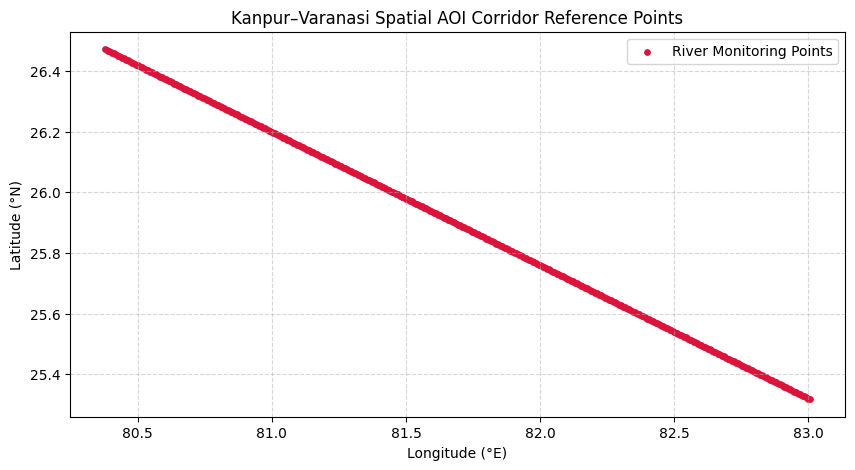

In [2]:
plt.figure(figsize=(10, 5))
plt.scatter(df_wq['Longitude'], df_wq['Latitude'], color='crimson', s=15, label='River Monitoring Points')
plt.title('Kanpur–Varanasi Spatial AOI Corridor Reference Points')
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
